***

## Implement Base Model for Co-Teaching

In this notebook, we will do the following:
* Load the data from CIFAR10
* Create a base model
* Train it on clean data
* Get the loss values

***

In [1]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 27.6 MB/s eta 0:00:00


In [15]:
import torch
import numpy as np

# from google.colab import drive
import seaborn as sns

from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
from PIL import Image
import torchvision.transforms as transforms
from torchvision import datasets, models
import optuna

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torchvision


In [16]:
sns.set_style(style="darkgrid")

In [17]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# for CIFAR 10
cifar_10_mean = [0.4914, 0.4822, 0.4465]
cifar_10_std  = [0.2470, 0.2435, 0.2616]

# for CIFAR 100
cifar_100_mean = [0.5071, 0.4867, 0.4408]
cifar_100_std  = [0.2675, 0.2565, 0.2761]

# ------------------------------------------------------
# Transformations (same style as you provided)
# ------------------------------------------------------
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # transforms.RandomCrop((224,224)),
    # transforms.RandomHorizontalFlip(),
    transforms.Normalize(mean=cifar_10_mean, std=cifar_10_std)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.CenterCrop(224),
    transforms.Normalize(mean=cifar_10_mean, std=cifar_10_std)
])

# ------------------------------------------------------
# CIFAR-10 Dataset Import (NO NOISE)
# ------------------------------------------------------
train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=8,
    persistent_workers=True
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=8,
    persistent_workers=True
)



In [18]:
train_dataloader

In [19]:
# validating the image and labels shape
for images, labels in train_dataloader:
  print(images.shape)
  print(labels.shape)
  break

torch.Size([64, 3, 224, 224])
torch.Size([64])


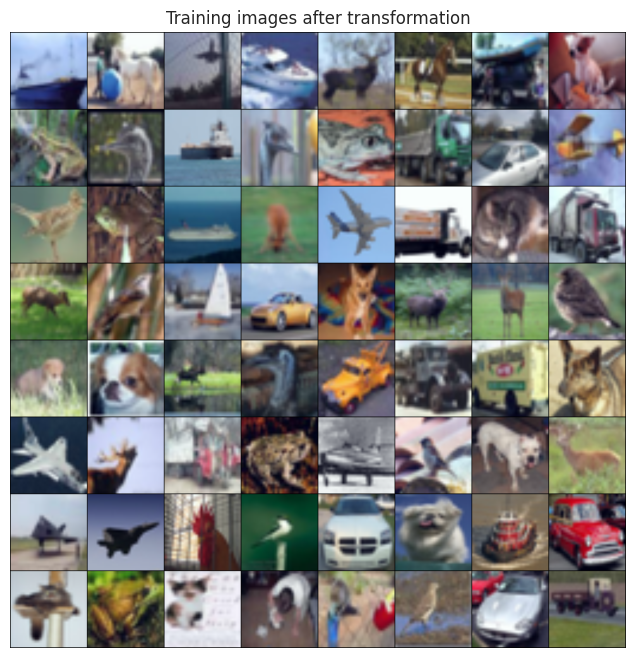

In [20]:
for images, labels in train_dataloader:
    break

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training images after transformation")
plt.imshow(np.transpose(torchvision.utils.make_grid(
    images[:64],
    padding=2,
    normalize=True),
    (1, 2, 0)))
plt.show()

In [21]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("MPS is available. Using:", device)
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("CUDA is available. Using:", device)
else:
    device = torch.device("cpu")
    print("MPS not available. Using CPU instead.")

CUDA is available. Using: cuda


***

Defining the model mentioned in the co-teaching paper

***

In [22]:
import math
import torch
import torch.nn as nn
import torch.nn.init as init
import torch.nn.functional as F
import torch.optim as optim

In [23]:
def call_bn(bn, x):
    return bn(x)

class CNN(nn.Module):
    def __init__(self, input_channel=3, n_outputs=10, dropout_rate=0.25, top_bn=False):
        self.dropout_rate = dropout_rate
        self.top_bn = top_bn
        super(CNN, self).__init__()
        self.c1=nn.Conv2d(input_channel,128,kernel_size=3,stride=1, padding=1)
        self.c2=nn.Conv2d(128,128,kernel_size=3,stride=1, padding=1)
        self.c3=nn.Conv2d(128,128,kernel_size=3,stride=1, padding=1)
        self.c4=nn.Conv2d(128,256,kernel_size=3,stride=1, padding=1)
        self.c5=nn.Conv2d(256,256,kernel_size=3,stride=1, padding=1)
        self.c6=nn.Conv2d(256,256,kernel_size=3,stride=1, padding=1)
        self.c7=nn.Conv2d(256,512,kernel_size=3,stride=1, padding=0)
        self.c8=nn.Conv2d(512,256,kernel_size=3,stride=1, padding=0)
        self.c9=nn.Conv2d(256,128,kernel_size=3,stride=1, padding=0)
        self.l_c1=nn.Linear(128,n_outputs)
        self.bn1=nn.BatchNorm2d(128)
        self.bn2=nn.BatchNorm2d(128)
        self.bn3=nn.BatchNorm2d(128)
        self.bn4=nn.BatchNorm2d(256)
        self.bn5=nn.BatchNorm2d(256)
        self.bn6=nn.BatchNorm2d(256)
        self.bn7=nn.BatchNorm2d(512)
        self.bn8=nn.BatchNorm2d(256)
        self.bn9=nn.BatchNorm2d(128)

    def forward(self, x,):
        h=x
        h=self.c1(h)
        h=F.leaky_relu(call_bn(self.bn1, h), negative_slope=0.01)
        h=self.c2(h)
        h=F.leaky_relu(call_bn(self.bn2, h), negative_slope=0.01)
        h=self.c3(h)
        h=F.leaky_relu(call_bn(self.bn3, h), negative_slope=0.01)
        h=F.max_pool2d(h, kernel_size=2, stride=2)
        h=F.dropout2d(h, p=self.dropout_rate)

        h=self.c4(h)
        h=F.leaky_relu(call_bn(self.bn4, h), negative_slope=0.01)
        h=self.c5(h)
        h=F.leaky_relu(call_bn(self.bn5, h), negative_slope=0.01)
        h=self.c6(h)
        h=F.leaky_relu(call_bn(self.bn6, h), negative_slope=0.01)
        h=F.max_pool2d(h, kernel_size=2, stride=2)
        h=F.dropout2d(h, p=self.dropout_rate)

        h=self.c7(h)
        h=F.leaky_relu(call_bn(self.bn7, h), negative_slope=0.01)
        h=self.c8(h)
        h=F.leaky_relu(call_bn(self.bn8, h), negative_slope=0.01)
        h=self.c9(h)
        h=F.leaky_relu(call_bn(self.bn9, h), negative_slope=0.01)
        h=F.avg_pool2d(h, kernel_size=h.data.shape[2])

        h = h.view(h.size(0), h.size(1))
        logit=self.l_c1(h)
        if self.top_bn:
            logit=call_bn(self.bn_c1, logit)
        return logit

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNNFast(nn.Module):
    def __init__(self, input_channel=3, n_outputs=10, dropout_rate=0.25, top_bn=False):
        super().__init__()
        self.dropout_rate = dropout_rate
        self.top_bn = top_bn

        # conv blocks
        self.c1 = nn.Conv2d(input_channel, 128, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(128)
        self.act1 = nn.LeakyReLU(0.01, inplace=True)

        self.c2 = nn.Conv2d(128, 128, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.act2 = nn.LeakyReLU(0.01, inplace=True)

        self.c3 = nn.Conv2d(128, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.act3 = nn.LeakyReLU(0.01, inplace=True)

        self.c4 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.act4 = nn.LeakyReLU(0.01, inplace=True)

        self.c5 = nn.Conv2d(256, 256, 3, padding=1)
        self.bn5 = nn.BatchNorm2d(256)
        self.act5 = nn.LeakyReLU(0.01, inplace=True)

        self.c6 = nn.Conv2d(256, 256, 3, padding=1)
        self.bn6 = nn.BatchNorm2d(256)
        self.act6 = nn.LeakyReLU(0.01, inplace=True)

        self.c7 = nn.Conv2d(256, 512, 3, padding=0)
        self.bn7 = nn.BatchNorm2d(512)
        self.act7 = nn.LeakyReLU(0.01, inplace=True)

        self.c8 = nn.Conv2d(512, 256, 3, padding=0)
        self.bn8 = nn.BatchNorm2d(256)
        self.act8 = nn.LeakyReLU(0.01, inplace=True)

        self.c9 = nn.Conv2d(256, 128, 3, padding=0)
        self.bn9 = nn.BatchNorm2d(128)
        self.act9 = nn.LeakyReLU(0.01, inplace=True)

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128, n_outputs)

    def forward(self, x):
        x = self.act1(self.bn1(self.c1(x)))
        x = self.act2(self.bn2(self.c2(x)))
        x = self.act3(self.bn3(self.c3(x)))
        x = F.max_pool2d(x, 2, 2)
        x = F.dropout2d(x, p=self.dropout_rate, training=self.training)

        x = self.act4(self.bn4(self.c4(x)))
        x = self.act5(self.bn5(self.c5(x)))
        x = self.act6(self.bn6(self.c6(x)))
        x = F.max_pool2d(x, 2, 2)
        x = F.dropout2d(x, p=self.dropout_rate, training=self.training)

        x = self.act7(self.bn7(self.c7(x)))
        x = self.act8(self.bn8(self.c8(x)))
        x = self.act9(self.bn9(self.c9(x)))

        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN_small(nn.Module):
    def __init__(self, input_channel=3, n_outputs=10, dropout_rate=0.25, top_bn=False):
        super().__init__()
        self.dropout_rate = dropout_rate
        self.top_bn = top_bn

        # conv blocks
        self.c1 = nn.Conv2d(input_channel, 64, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.act1 = nn.LeakyReLU(0.01, inplace=True)

        self.c2 = nn.Conv2d(64, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.act2 = nn.LeakyReLU(0.01, inplace=True)

        self.c3 = nn.Conv2d(64, 32, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(32)
        self.act3 = nn.LeakyReLU(0.01, inplace=True)

        self.c4 = nn.Conv2d(32, 32, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(32)
        self.act4 = nn.LeakyReLU(0.01, inplace=True)

        self.c5 = nn.Conv2d(32, 32, 3, padding=1)
        self.bn5 = nn.BatchNorm2d(32)
        self.act5 = nn.LeakyReLU(0.01, inplace=True)

        # self.c6 = nn.Conv2d(256, 256, 3, padding=1)
        # self.bn6 = nn.BatchNorm2d(256)
        # self.act6 = nn.LeakyReLU(0.01, inplace=True)

        # self.c7 = nn.Conv2d(256, 512, 3, padding=0)
        # self.bn7 = nn.BatchNorm2d(512)
        # self.act7 = nn.LeakyReLU(0.01, inplace=True)

        # self.c8 = nn.Conv2d(512, 256, 3, padding=0)
        # self.bn8 = nn.BatchNorm2d(256)
        # self.act8 = nn.LeakyReLU(0.01, inplace=True)

        # self.c9 = nn.Conv2d(256, 128, 3, padding=0)
        # self.bn9 = nn.BatchNorm2d(128)
        # self.act9 = nn.LeakyReLU(0.01, inplace=True)

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(32, n_outputs)

    def forward(self, x):
        x = self.act1(self.bn1(self.c1(x)))
        x = self.act2(self.bn2(self.c2(x)))
        x = self.act3(self.bn3(self.c3(x)))
        x = F.max_pool2d(x, 2, 2)
        x = F.dropout2d(x, p=self.dropout_rate, training=self.training)

        x = self.act4(self.bn4(self.c4(x)))
        x = self.act5(self.bn5(self.c5(x)))
        # x = self.act6(self.bn6(self.c6(x)))
        # x = F.max_pool2d(x, 2, 2)
        # x = F.dropout2d(x, p=self.dropout_rate, training=self.training)

        # x = self.act7(self.bn7(self.c7(x)))
        # x = self.act8(self.bn8(self.c8(x)))
        # x = self.act9(self.bn9(self.c9(x)))

        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np

LEARNING_RATE = 0.01
NUM_EPOCHS=30


# Initialize the model (using CNN_small from the first snippet)
Base_Model = CNN_small().to(device)

# Define Loss and Optimizer (standard pattern from the second snippet, but with LR from the first snippet)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(Base_Model.parameters(), lr=LEARNING_RATE)
# Note: A learning rate of 0.01 is often high for deep CNNs with Adam,
# but we use it as requested by the first snippet's variables.

print(f"--- Starting Training on {device} ---")
print(f"Model: CNN_small")
print(f"Epochs: {NUM_EPOCHS}, Learning Rate: {LEARNING_RATE}")
print(f"Total training batches: {len(train_dataloader)}")

# --- Training Loop (Pattern from the second snippet) ---

train_loss = []
train_accuracy=[]
test_accuracy = []

for epoch in range(NUM_EPOCHS):
    Base_Model.train()
    running_loss = 0.0

    # Training Phase
    for batch_idx, (images, labels) in enumerate(train_dataloader):
        images, labels = images.to(device), labels.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = Base_Model(images)

        # Calculate loss (Standard CrossEntropyLoss, replacing co-teaching loss)
        loss = criterion(outputs, labels)

        # Backward pass and optimization step
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Print batch progress every 100 batches
        if batch_idx % 100 == 0:
            print(f"Epoch: {epoch+1:02d}/{NUM_EPOCHS:02d} | Batch: {batch_idx:03d}/{len(train_dataloader):03d} | Loss: {loss.item():.4f}")


    # Calculate average training loss for the epoch
    avg_train_loss = running_loss / len(train_dataloader)
    train_loss.append(avg_train_loss)

    # Calculate training accuracy
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in train_dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = Base_Model(images)
            predicted = outputs.argmax(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    train_accuracy_score = 100 * correct / total
    train_accuracy.append(train_accuracy_score)
    # Evaluation Phase
    Base_Model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = Base_Model(images)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_accuracy_score = 100 * correct / total
    test_accuracy.append(test_accuracy_score)

    # Print Epoch Summary (Pattern from the second snippet)
    print(f"\n--- Epoch {epoch+1:02d}/{NUM_EPOCHS:02d} Summary ---")
    print(f"Train Loss = {avg_train_loss:.4f}")
    print(f"Train Accuracy = {train_accuracy_score:.2f}%")
    print(f"Test Accuracy = {test_accuracy_score:.2f}%\n")

print("--- Training Complete ---")

--- Starting Training on cuda ---
Model: CNN_small
Epochs: 30, Learning Rate: 0.01
Total training batches: 782
Epoch: 01/30 | Batch: 000/782 | Loss: 2.3152
Epoch: 01/30 | Batch: 100/782 | Loss: 2.0981
Epoch: 01/30 | Batch: 200/782 | Loss: 2.1045
Epoch: 01/30 | Batch: 300/782 | Loss: 1.9459
Epoch: 01/30 | Batch: 400/782 | Loss: 1.9126
Epoch: 01/30 | Batch: 500/782 | Loss: 1.9925
Epoch: 01/30 | Batch: 600/782 | Loss: 1.8969
Epoch: 01/30 | Batch: 700/782 | Loss: 1.9902

--- Epoch 01/30 Summary ---
Train Loss = 1.9980
Train Accuracy = 26.53%
Test Accuracy = 27.61%

Epoch: 02/30 | Batch: 000/782 | Loss: 1.9873
Epoch: 02/30 | Batch: 100/782 | Loss: 1.9394
Epoch: 02/30 | Batch: 200/782 | Loss: 1.8890
Epoch: 02/30 | Batch: 300/782 | Loss: 2.0797
Epoch: 02/30 | Batch: 400/782 | Loss: 1.8497
Epoch: 02/30 | Batch: 500/782 | Loss: 1.9450
Epoch: 02/30 | Batch: 600/782 | Loss: 1.7546
Epoch: 02/30 | Batch: 700/782 | Loss: 1.9575

--- Epoch 02/30 Summary ---
Train Loss = 1.9302
Train Accuracy = 30.84%

In [37]:
import os

save_dir = "/content/drive/MyDrive/project_CNN_noisy_label_base"

os.makedirs(save_dir, exist_ok=True)

print("Folder created at:", save_dir)


Folder created at: /content/drive/MyDrive/project_CNN_noisy_label_base


In [38]:
print(train_accuracy)
print(test_accuracy)
print(train_loss)

[26.528, 30.838, 33.866, 37.396, 39.316, 43.838, 44.532, 47.64, 48.794, 50.112, 49.062, 49.656, 51.884, 52.548, 52.898, 54.158, 53.648, 54.004, 55.722, 55.568, 55.472, 55.62, 56.102, 56.126, 55.83, 56.52, 55.906, 57.884, 57.802, 57.428]
[27.61, 33.78, 35.64, 38.81, 41.19, 45.33, 45.92, 48.4, 49.83, 51.28, 50.02, 50.71, 53.67, 54.34, 53.72, 55.04, 53.68, 56.12, 56.74, 56.76, 56.69, 56.5, 57.05, 57.47, 56.59, 57.51, 57.32, 58.59, 58.73, 58.45]
[1.9980372862742686, 1.9302050295998068, 1.8225032860970558, 1.741181598752356, 1.682714336668439, 1.6158307225198087, 1.542281178409791, 1.5021456326060283, 1.4722572475138223, 1.4348911796994221, 1.4151143494164546, 1.387647792811284, 1.3697218891909666, 1.3555062821758983, 1.3451623796197154, 1.3290866552411442, 1.3175473611830446, 1.308013586055897, 1.2912590332958094, 1.2776636703087545, 1.2717913613295007, 1.2605844914455853, 1.252494150110523, 1.245964271104549, 1.2307632298725646, 1.226534047090184, 1.2203988604380955, 1.213969737977323, 1.

In [40]:
torch.save(Base_Model,"/content/drive/MyDrive/project_CNN_noisy_label_base/Base_Model_CIFAR10.pth")
metrics = {
    "Name":"BaseModel CNN Cifar10",
    "train_loss": train_loss,
    "train_accuracy": train_accuracy,
    "test_accuracy": test_accuracy
}

torch.save(metrics,
           "/content/drive/MyDrive/project_CNN_noisy_label_base/training_metrics_BASEMODEL_CIFAR10.pth")